In [7]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [10]:
def extract_signatures_from_red_boxes(image_path, output_folder='extracted_signatures', min_area=500):
    """
    Extracts all signatures from inside red boxes in an image.
    
    Parameters:
    - image_path: Path to the input image
    - output_folder: Folder where extracted signatures will be saved
    - min_area: Minimum area (in pixels) for a contour to be considered a red box
    
    Returns:
    - signatures: List of extracted signature regions as numpy arrays
    """
    
    # Create output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image from {image_path}")
    
    # Convert to RGB for display (OpenCV uses BGR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Convert to HSV color space for better color detection
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Define range for red color in HSV
    # Red color wraps around in HSV, so we need two ranges
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    
    # Create masks for red color
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask = cv2.bitwise_or(mask1, mask2)
    
    # Apply morphological operations to clean up the mask
    kernel = np.ones((5, 5), np.uint8)
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, kernel)
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)
    
    # Find contours of all red boxes
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        raise ValueError("No red boxes detected in the image")
    
    # Filter contours by area to avoid small noise
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
    
    if not valid_contours:
        raise ValueError(f"No red boxes with area > {min_area} pixels detected")
    
    print(f"Found {len(valid_contours)} red box(es)")
    
    # Sort contours by position (top to bottom, left to right)
    bounding_boxes = [cv2.boundingRect(cnt) for cnt in valid_contours]
    sorted_indices = sorted(range(len(bounding_boxes)), 
                           key=lambda i: (bounding_boxes[i][1], bounding_boxes[i][0]))
    
    signatures = []
    img_with_boxes = img_rgb.copy()
    
    # Process each red box
    for idx, contour_idx in enumerate(sorted_indices):
        x, y, w, h = bounding_boxes[contour_idx]
        
        # Draw rectangle on visualization image
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_with_boxes, f"#{idx+1}", (x, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        
        # Add inward padding to exclude the red box border
        border_thickness = 5  # Adjust based on your red box border thickness
        x1 = max(0, x + border_thickness)
        y1 = max(0, y + border_thickness)
        x2 = min(img.shape[1], x + w - border_thickness)
        y2 = min(img.shape[0], y + h - border_thickness)
        
        # Skip if the box is too small after border removal
        if x2 <= x1 or y2 <= y1:
            print(f"Warning: Box #{idx+1} is too small after border removal, skipping...")
            continue
        
        # Crop the signature region (excluding the red border)
        cropped_signature = img_rgb[y1:y2, x1:x2]
        
        # Remove any remaining red pixels
        signature_cleaned = cropped_signature.copy()
        
        # Convert to HSV for the cropped region
        signature_bgr = cv2.cvtColor(signature_cleaned, cv2.COLOR_RGB2BGR)
        signature_hsv = cv2.cvtColor(signature_bgr, cv2.COLOR_BGR2HSV)
        
        # Create mask for red pixels in the cropped signature
        red_pixels_mask1 = cv2.inRange(signature_hsv, lower_red1, upper_red1)
        red_pixels_mask2 = cv2.inRange(signature_hsv, lower_red2, upper_red2)
        red_pixels_mask = cv2.bitwise_or(red_pixels_mask1, red_pixels_mask2)
        
        # Replace red pixels with white
        signature_cleaned[red_pixels_mask > 0] = [255, 255, 255]
        
        # Save the signature
        output_path = os.path.join(output_folder, f'signature_{idx+1}.png')
        Image.fromarray(signature_cleaned).save(output_path)
        signatures.append(signature_cleaned)
        
        print(f"Signature #{idx+1} extracted: x={x}, y={y}, width={w}, height={h}")
        print(f"  Saved to: {output_path}")
    
    # Visualize the results
    num_signatures = len(signatures)
    if num_signatures > 0:
        # Determine grid layout
        total_plots = num_signatures + 2  # +2 for original and detected images
        cols = min(3, total_plots)  # Max 3 columns
        rows = (total_plots + cols - 1) // cols  # Ceiling division
        
        plt.figure(figsize=(5 * cols, 5 * rows))
        
        # Original image
        plt.subplot(rows, cols, 1)
        plt.imshow(img_rgb)
        plt.title('Original Image')
        plt.axis('off')
        
        # Image with detected red boxes
        plt.subplot(rows, cols, 2)
        plt.imshow(img_with_boxes)
        plt.title(f'Detected {num_signatures} Red Box(es)')
        plt.axis('off')
        
        # Extracted signatures
        for idx, sig in enumerate(signatures):
            plt.subplot(rows, cols, idx + 3)
            plt.imshow(sig)
            plt.title(f'Signature #{idx+1}')
            plt.axis('off')
        
        plt.tight_layout()
        viz_path = os.path.join(output_folder, 'extraction_visualization.png')
        plt.savefig(viz_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nVisualization saved to: {viz_path}")
    
    return signatures

Found 2 red box(es)
Signature #1 extracted: x=2728, y=3953, width=763, height=410
  Saved to: extracted_signature.png\signature_1.png
Signature #2 extracted: x=928, y=3957, width=755, height=406
  Saved to: extracted_signature.png\signature_2.png


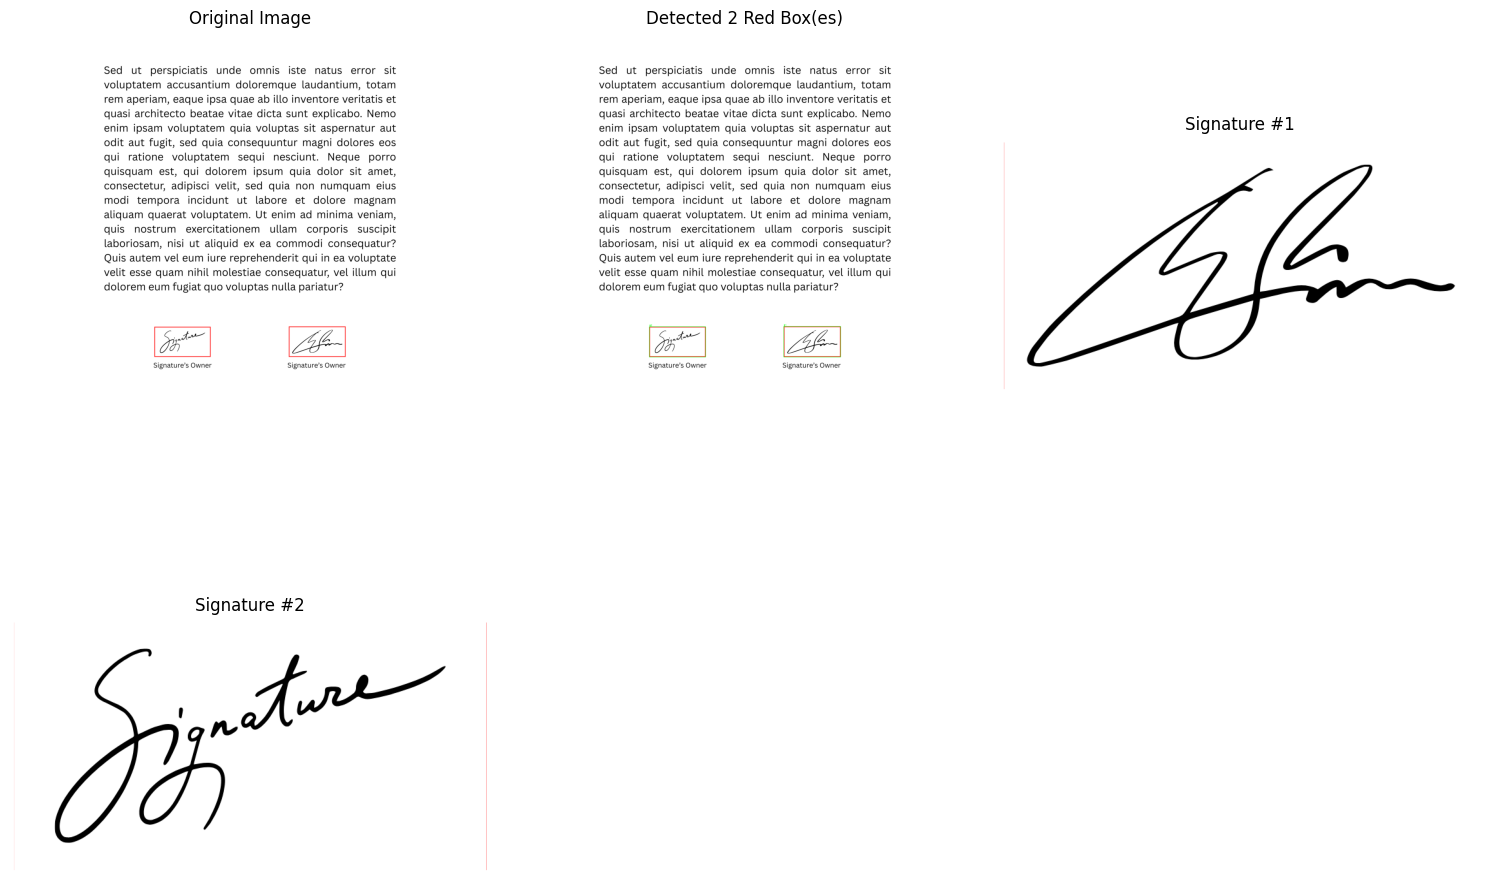


Visualization saved to: extracted_signature.png\extraction_visualization.png
[array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        

In [13]:
input_image = "docu_example.png"
output_image = "extracted_signature.png"

try:
    signatures = extract_signatures_from_red_boxes(input_image, output_image)
    print(signatures)
    print("Signature extraction completed successfully!")
except Exception as e:
    print(f"Error: {e}")
    print("\nMake sure:")
    print("1. The image file exists at the specified path")
    print("2. The image contains a red box around the signature")
    print("3. OpenCV and other required libraries are installed")